[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bloom\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Запрос start=0, max_results=200
Запрос start=200, max_results=200
Запрос start=400, max_results=200
Запрос start=600, max_results=200
Запрос start=800, max_results=200


2025-10-06 00:41:52 INFO: Downloaded file to C:\Users\bloom\stanza_resources\resources.json
2025-10-06 00:41:52 INFO: Downloading default packages for language: en (English) ...
2025-10-06 00:41:52 INFO: File exists: C:\Users\bloom\stanza_resources\en\default.zip
2025-10-06 00:41:54 INFO: Finished downloading models and saved to C:\Users\bloom\stanza_resources
2025-10-06 00:41:54 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-10-06 00:41:58 INFO: Downloaded file to C:\Users\bloom\stanza_resources\resources.json
2025-10-06 00:41:58 WARNING: Language en package default expects mwt, which has been added
2025-10-06 00:41:58 INFO: Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| lemma     | combined_nochar

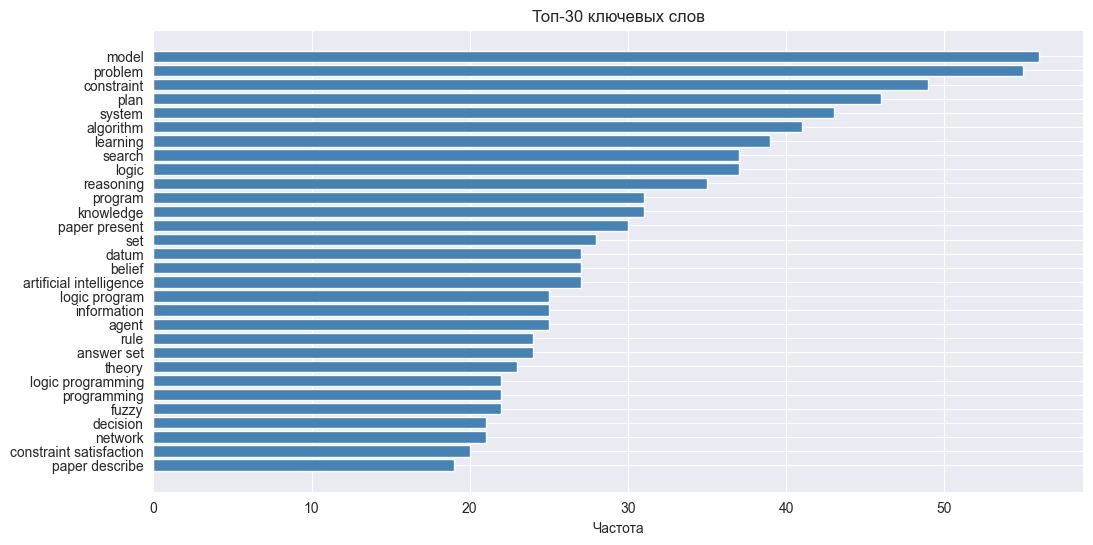

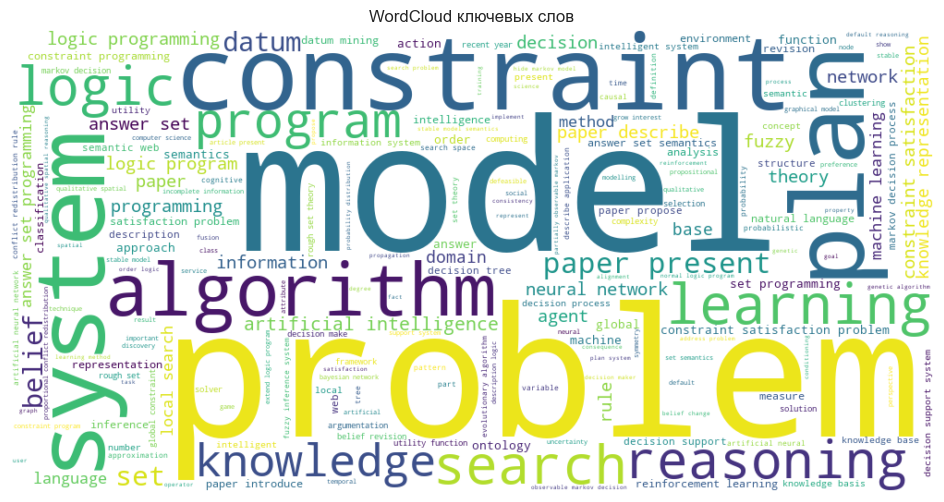

Модулярность кластеризации: 0.7880720450403916

=== Интерпретация кластеров Louvain ===

Кластер 0 — вероятная тема:
erase meaningful progress, solving search, meaningful progress, return shallow, shallow point, dynamic backtracking, dynamic, exist backtracking, erase meaningful, exist backtracking method

Кластер 1 — вероятная тема:
tree, small consistent decision, consistent decision tree, occam razor, decision, decision tree consistent, decision forest, decision tree, empirical investigation, consistent decision

Кластер 2 — вероятная тема:
search tree, analysis, method, diverging proof attempt, proof, critic, diverge, inductive theorem, identify diverging proof, inductive theorem prover

Кластер 3 — вероятная тема:
search problem, practical application, account semantic property, decompose solve, satisfaction problem, solve functional csp, generally assume, semantic property, order increase, search efficiency

Кластер 4 — вероятная тема:
search, article describe, enable efficient a

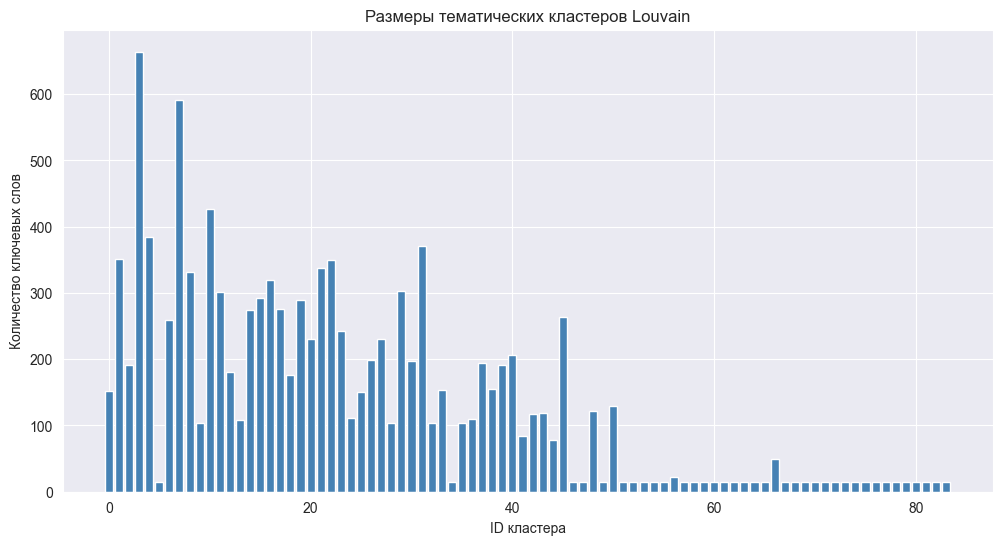

In [ ]:
import requests, time, xml.etree.ElementTree as ET
import pandas as pd
import yake, stanza, nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import networkx as nx
import itertools
from nltk.corpus import stopwords
from community import community_louvain

# Настройка отображения
plt.rcParams['figure.figsize'] = (12,6)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Пространства имён arXiv API
NS = {
    'atom': 'http://www.w3.org/2005/Atom',
    'opensearch': 'http://a9.com/-/spec/opensearch/1.1/',
    'arxiv': 'http://arxiv.org/schemas/atom'
}

# === 1. Скачивание данных ===
def parse_entry(entry_elem):
    def get_text(path):
        el = entry_elem.find(path, NS)
        return el.text.strip() if el is not None and el.text else ""
    return {
        "id": get_text('atom:id'),
        "title": get_text('atom:title'),
        "summary": get_text('atom:summary'),
        "authors": [a.find('atom:name', NS).text.strip()
                    for a in entry_elem.findall('atom:author', NS)
                    if a.find('atom:name', NS) is not None],
        "categories": [c.attrib.get('term')
                       for c in entry_elem.findall('atom:category', NS)]
    }

def fetch_arxiv(search_query="cat:cs.AI", total=1000, per_call=200, sleep_s=3.0):
    API_ENDPOINT = "http://export.arxiv.org/api/query"
    results, start = [], 0
    while len(results) < total:
        to_request = min(per_call, total - len(results))
        params = {"search_query": search_query, "start": start, "max_results": to_request}
        print(f"Запрос start={start}, max_results={to_request}")
        resp = requests.get(API_ENDPOINT, params=params, timeout=60)
        resp.raise_for_status()
        root = ET.fromstring(resp.text)
        entries = root.findall('atom:entry', NS)
        if not entries:
            break
        for e in entries:
            results.append(parse_entry(e))
            if len(results) >= total:
                break
        start += to_request
        if len(results) < total:
            time.sleep(sleep_s)
    return results

# Загружаем публикации
data = fetch_arxiv("cat:cs.AI", total=1000, per_call=200)
df = pd.DataFrame(data)

# === 2. Извлечение ключевых слов ===
yake_extractor = yake.KeywordExtractor(lan="en", n=3, dedupLim=0.85, top=15)

def extract_keywords(text):
    text = text.lower()
    keywords = yake_extractor.extract_keywords(text)
    return [kw[0] for kw in keywords]

df["keywords"] = (df["title"] + " " + df["summary"]).apply(extract_keywords)

# Лемматизация через stanza
stanza.download('en')
nlp = stanza.Pipeline('en', processors='tokenize,lemma', use_gpu=False)

def lemmatize_keywords(keywords):
    lemmas = []
    for phrase in keywords:
        doc = nlp(phrase)
        lemmatized_words = [word.lemma for word in doc.iter_words()]
        lemmas.append(" ".join(lemmatized_words))
    return lemmas

df["lemmatized_keywords"] = df["keywords"].apply(lemmatize_keywords)

# Очистка от стоп-слов
def clean_keywords(keywords):
    cleaned = []
    for phrase in keywords:
        words = phrase.split()
        filtered = [w for w in words if w not in stop_words]
        if filtered:
            cleaned.append(" ".join(filtered))
    return cleaned

df["cleaned_keywords"] = df["lemmatized_keywords"].apply(clean_keywords)

# === 3. Частотный анализ ключевых слов ===
all_keywords = [kw for kws in df["cleaned_keywords"] for kw in kws]
keyword_freq = Counter(all_keywords)

# Top-30
most_common = keyword_freq.most_common(30)
top_words = [w for w,_ in most_common]
top_counts = [c for _,c in most_common]

plt.figure(figsize=(12,6))
plt.barh(top_words[::-1], top_counts[::-1], color='steelblue')
plt.xlabel("Частота")
plt.title("Топ-30 ключевых слов")
plt.show()

# WordCloud
wordcloud = WordCloud(width=1000, height=500, background_color="white").generate_from_frequencies(keyword_freq)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud ключевых слов")
plt.show()

# === 4. Граф ключевых слов ===
G = nx.Graph()
for keywords in df["cleaned_keywords"]:
    for w1, w2 in itertools.combinations(set(keywords), 2):
        if G.has_edge(w1, w2):
            G[w1][w2]["weight"] += 1
        else:
            G.add_edge(w1, w2, weight=1)

# Кластеризация Louvain + модулярность
partition = community_louvain.best_partition(G, weight="weight")
nx.set_node_attributes(G, partition, "community")
modularity = community_louvain.modularity(partition, G, weight='weight')
print("Модулярность кластеризации:", modularity)

# Интерпретация кластеров
cluster_words = {}
for node, cluster_id in partition.items():
    cluster_words.setdefault(cluster_id, []).append(node)

print("\n=== Интерпретация кластеров Louvain ===")
cluster_summaries = {}
for cid, words in cluster_words.items():
    counter = Counter(words)
    top_terms = [w for w, _ in counter.most_common(10)]
    cluster_summaries[cid] = top_terms
    print(f"\nКластер {cid} — вероятная тема:")
    print(", ".join(top_terms))

plt.figure(figsize=(12,6))
cluster_sizes = [len(words) for words in cluster_words.values()]
plt.bar(range(len(cluster_sizes)), cluster_sizes, color='steelblue')
plt.xlabel("ID кластера")
plt.ylabel("Количество ключевых слов")
plt.title("Размеры тематических кластеров Louvain")
plt.show()

# Центральности
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, weight="weight")
eigenvector_centrality = nx.eigenvector_centrality(G, weight="weight")
closeness_centrality = nx.closeness_centrality(G)

centralities = {
    "Degree": degree_centrality,
    "Betweenness": betweenness_centrality,
    "Eigenvector": eigenvector_centrality,
    "Closeness": closeness_centrality
}

for name, cent in centralities.items():
    top10 = sorted(cent.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"\nTop-10 по {name} centrality:")
    for word, score in top10:
        print(f"{word}: {score:.4f}")

# Визуализация графа ключевых слов
colors = [partition[n] for n in G.nodes()]
plt.figure(figsize=(14,10))
pos = nx.spring_layout(G, k=0.15, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=50, node_color=colors, cmap=plt.cm.tab20)
nx.draw_networkx_edges(G, pos, alpha=0.2)
plt.title("Граф ключевых слов с кластерами (Louvain)")
plt.axis('off')
plt.show()

# === 5. Граф публикаций ===
H = nx.Graph()
for i, row in df.iterrows():
    H.add_node(i, title=row["title"])

for i, j in itertools.combinations(df.index, 2):
    common = set(df.loc[i, "cleaned_keywords"]) & set(df.loc[j, "cleaned_keywords"])
    if common:
        H.add_edge(i, j, weight=len(common))

# Фильтрация сильных связей
min_weight = 2
strong_edges = [(u, v, d) for u, v, d in H.edges(data=True) if d['weight'] >= min_weight]
H_strong = nx.Graph()
H_strong.add_nodes_from(H.nodes(data=True))
H_strong.add_edges_from(strong_edges)
print(f"Граф публикаций после фильтрации (ребра >= {min_weight}): узлов={H_strong.number_of_nodes()}, рёбер={H_strong.number_of_edges()}")

# Визуализация графа публикаций
plt.figure(figsize=(16,12))
pos = nx.spring_layout(H_strong, k=0.15, seed=42)
nx.draw_networkx_nodes(H_strong, pos, node_size=50, node_color='skyblue')
edge_widths = [d['weight'] for (_, _, d) in H_strong.edges(data=True)]
nx.draw_networkx_edges(H_strong, pos, width=edge_widths, alpha=0.5)
plt.title(f"Граф публикаций (только связи с >= {min_weight} общими ключевыми словами)")
plt.axis('off')
plt.show()

# Поиск похожих публикаций
def find_similar_papers_strong(idx, top_n=5):
    if idx not in H_strong:
        print(f"Публикация с индексом {idx} отсутствует в графе (слишком слабые связи).")
        return []

    neighbors = list(H_strong[idx])
    if not neighbors:
        print(f"Для публикации '{df.loc[idx, 'title']}' не найдено близких по ключевым словам статей.")
        return []

    scores = [(n, H_strong[idx][n]['weight']) for n in neighbors]
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[:top_n]

    print(f"\nПохожие публикации на статью:\n«{df.loc[idx, 'title']}»\n")
    results = []
    for n, weight in scores:
        common = sorted(set(df.loc[idx, "cleaned_keywords"]) & set(df.loc[n, "cleaned_keywords"]))
        print(f"— {df.loc[n, 'title']}")
        print(f"  Общие ключевые слова ({len(common)}): {', '.join(common[:8])}{'...' if len(common) > 8 else ''}")
        print(f"  Вес связи: {weight}\n")
        results.append((df.loc[n, "title"], weight, common))
    return results

# Пример использования
find_similar_papers_strong(0, top_n=5)

# Добавляем кластеры для публикаций
df["cluster_id"] = df["cleaned_keywords"].apply(
    lambda kws: Counter(partition.get(k, -1) for k in kws if k in partition).most_common(1)[0][0]
    if kws else -1
)

# Краткое имя темы
cluster_names = {cid: ", ".join(words[:3]) for cid, words in cluster_summaries.items()}
df["cluster_name"] = df["cluster_id"].map(cluster_names)

# Прогон для всех статей и сохранение в файл рядом со скриптом
similarities = {}

for idx in df.index:
    result = find_similar_papers_strong(idx, top_n=5)
    similarities[idx] = result

# Собираем всё в DataFrame
all_similar = []
for idx, sims in similarities.items():
    for title, weight, common in sims:
        all_similar.append({
            "source_idx": idx,
            "source_title": df.loc[idx, "title"],
            "source_cluster": df.loc[idx, "cluster_name"],
            "similar_title": title,
            "weight": weight,
            "common_keywords": ", ".join(common)
        })

all_similar_df = pd.DataFrame(all_similar)

all_similar_df.to_csv("similar_papers_with_clusters.csv", index=False, encoding="utf-8")

print("Файл 'similar_papers_with_clusters.csv' сохранён в текущей директории.")
